# Upper-agent learning causality verification

This notebook tests whether the current runtime gives PPO a learnable causal signal:

`upper bias → release quota → local offset → A3 candidates → admitted HOs → load improvement → reward`

It does **not** assume the mechanism passes. It compares identical seeds and reports which links in the chain work and which links remain blocked.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from global_ppo_3gnb_env import GlobalPPO3GNBEnv

SEED = 123
print(f"Repository root: {ROOT}")
print(f"Deterministic comparison seed: {SEED}")

Repository root: /home/oussama/Desktop/chech
Deterministic comparison seed: 123


## Deterministic episode runner

Only the gNB0/eMBB bias changes. Every run recreates and resets the environment with the same seed.

In [2]:
def action_for_g0_embb(bias):
    action = np.zeros(9, dtype=np.float32)
    action[0] = float(bias)
    return action


def run_episode(scenario, bias, seed=SEED):
    env = GlobalPPO3GNBEnv(
        seed=seed,
        scenario_mode="curriculum",
        training_scenarios=scenario,
        scenario_selection="cycle",
        upper_window_seconds=1.0,
        local_steps_per_global=10,
        radio_substeps=2,
        terminal_reward_only=False,
        global_neutral_bias_weight=0.05,
        global_bad_direction_eta=0.05,
        global_unsafe_target_rho=0.10,
        load_balance_level_weight=0.50,
        a3_handover_cooldown_s=5.0,
        a3_min_residence_s=5.0,
    )
    rows = []
    try:
        _obs, reset_info = env.reset(seed=seed)
        action = action_for_g0_embb(bias)
        while True:
            _obs, reward, terminated, truncated, info = env.step(action)
            safe = info["safe_admission"]
            rows.append({
                "step": int(info["global_step"]),
                "reward": float(reward),
                "handovers": int(info["handover_count"]),
                "eligible": int(safe["stats"]["eligible"]),
                "quota": int(safe["quota"].get((0, "eMBB"), 0)),
                "used": int(safe["used"].get((0, "eMBB"), 0)),
                "imbalance_start": float(info["load_imbalance_start"]),
                "imbalance_end": float(info["load_imbalance_end"]),
                "offset_to_g1": float(np.asarray(info["strong_local_offsets"])[0, 0, 0]),
            })
            if terminated or truncated:
                break
        return {
            "scenario": scenario,
            "bias": float(bias),
            "initial_imbalance": rows[0]["imbalance_start"],
            "final_imbalance": rows[-1]["imbalance_end"],
            "episode_return": float(sum(row["reward"] for row in rows)),
            "total_handovers": int(sum(row["handovers"] for row in rows)),
            "total_eligible": int(sum(row["eligible"] for row in rows)),
            "max_quota": int(max(row["quota"] for row in rows)),
            "first_handover_step": next(
                (row["step"] for row in rows if row["handovers"] > 0), None
            ),
            "rows": rows,
        }
    finally:
        env.close()


def print_summary(results):
    header = f"{'bias':>6} {'quota':>6} {'HO':>4} {'first HO':>8} {'imbalance':>18} {'return':>9}"
    print(header)
    print("-" * len(header))
    for result in results:
        first = "-" if result["first_handover_step"] is None else str(result["first_handover_step"])
        imbalance = f"{result['initial_imbalance']:.3f}->{result['final_imbalance']:.3f}"
        print(
            f"{result['bias']:6.1f} {result['max_quota']:6d} "
            f"{result['total_handovers']:4d} {first:>8} "
            f"{imbalance:>18} {result['episode_return']:9.3f}"
        )

## Bias sweep on a radio-feasible crossing scenario

Expected evidence:

- negative bias creates a positive quota;
- larger magnitude creates a larger per-window quota and earlier/faster release;
- release reduces imbalance compared with neutral and retain actions;
- useful release earns more return than neutral, while wrong retain earns less.

In [3]:
SWEEP_BIASES = [0.5, 0.0, -0.1, -0.4, -0.8, -1.0]
crossing_results = [
    run_episode("fast_border_crossing_embb", bias)
    for bias in SWEEP_BIASES
]
print_summary(crossing_results)

  bias  quota   HO first HO          imbalance    return
--------------------------------------------------------
   0.5      0    0        -       0.448->0.448    -0.377
   0.0      0    0        -       0.448->0.448     0.000
  -0.1      1    7       12       0.448->0.170     0.272
  -0.4      3    7       10       0.448->0.170     0.210
  -0.8      6    7        9       0.448->0.170     0.041
  -1.0      7    7        8       0.448->0.170    -0.083


In [4]:
by_bias = {result["bias"]: result for result in crossing_results}
negative_results = [by_bias[bias] for bias in (-0.1, -0.4, -0.8, -1.0)]

checks_crossing = {
    "quota grows with |negative bias|": all(
        left["max_quota"] <= right["max_quota"]
        for left, right in zip(negative_results, negative_results[1:])
    ),
    "every negative action executes HOs": all(
        result["total_handovers"] > 0 for result in negative_results
    ),
    "useful release improves imbalance": (
        by_bias[-0.1]["final_imbalance"] < by_bias[0.0]["final_imbalance"]
    ),
    "correct release reward > neutral": (
        by_bias[-0.1]["episode_return"] > by_bias[0.0]["episode_return"]
    ),
    "neutral reward > wrong retain": (
        by_bias[0.0]["episode_return"] > by_bias[0.5]["episode_return"]
    ),
    "stronger release starts no later": (
        by_bias[-1.0]["first_handover_step"]
        <= by_bias[-0.4]["first_handover_step"]
        <= by_bias[-0.1]["first_handover_step"]
    ),
}

for name, passed in checks_crossing.items():
    print(f"{'PASS' if passed else 'FAIL'} - {name}")

# Hard safety invariant: successful HOs in a window never exceed its quota.
assert all(
    row["used"] <= row["quota"]
    for result in crossing_results
    for row in result["rows"]
)
assert all(checks_crossing.values())


PASS - quota grows with |negative bias|
PASS - every negative action executes HOs
PASS - useful release improves imbalance
PASS - correct release reward > neutral
PASS - neutral reward > wrong retain
PASS - stronger release starts no later


## Fixed-overlap diagnostic

This scenario is specifically described as teaching release intensity. We compare neutral and maximum release. If maximum release creates no A3 candidates or handovers, PPO cannot learn release behavior from this scenario: it sees the negative-bias penalty without a balancing benefit.

In [5]:
fixed_results = [
    run_episode("fixed_embb_g0_overlap", 0.0),
    run_episode("fixed_embb_g0_overlap", -1.0),
]
print_summary(fixed_results)

fixed_neutral, fixed_release = fixed_results
checks_fixed = {
    "release creates A3 candidates": fixed_release["total_eligible"] > 0,
    "release executes at least one HO": fixed_release["total_handovers"] > 0,
    "release improves imbalance": (
        fixed_release["final_imbalance"] < fixed_neutral["final_imbalance"]
    ),
    "release reward beats neutral": (
        fixed_release["episode_return"] > fixed_neutral["episode_return"]
    ),
}

for name, passed in checks_fixed.items():
    print(f"{'PASS' if passed else 'FAIL'} - {name}")

  bias  quota   HO first HO          imbalance    return
--------------------------------------------------------
   0.0      0    0        -       0.493->0.493     0.000
  -1.0      7    0        -       0.493->0.493    -0.170
FAIL - release creates A3 candidates
FAIL - release executes at least one HO
FAIL - release improves imbalance
FAIL - release reward beats neutral


## Curves: quota, timing, imbalance, and return

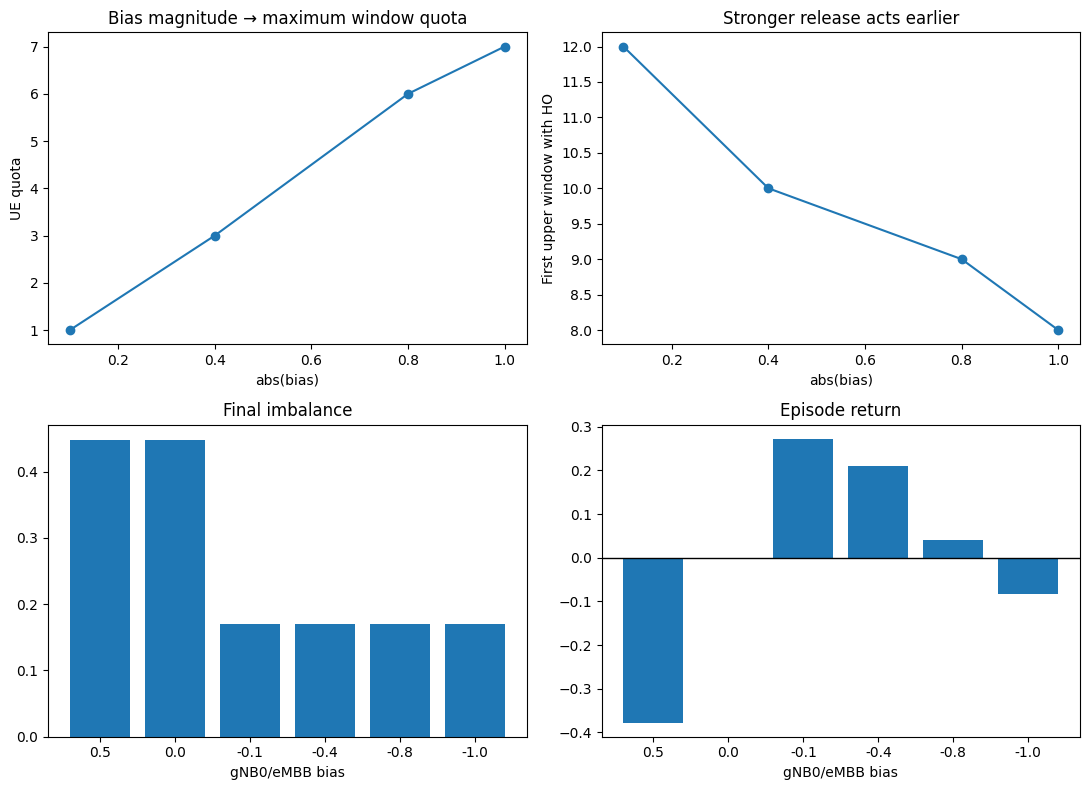

In [6]:
negative_biases = np.array([-0.1, -0.4, -0.8, -1.0])
negative = [by_bias[float(bias)] for bias in negative_biases]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(np.abs(negative_biases), [r["max_quota"] for r in negative], "o-")
axes[0, 0].set_title("Bias magnitude → maximum window quota")
axes[0, 0].set_xlabel("abs(bias)")
axes[0, 0].set_ylabel("UE quota")

axes[0, 1].plot(np.abs(negative_biases), [r["first_handover_step"] for r in negative], "o-")
axes[0, 1].set_title("Stronger release acts earlier")
axes[0, 1].set_xlabel("abs(bias)")
axes[0, 1].set_ylabel("First upper window with HO")

ordered = [by_bias[bias] for bias in SWEEP_BIASES]
axes[1, 0].bar([str(r["bias"]) for r in ordered], [r["final_imbalance"] for r in ordered])
axes[1, 0].set_title("Final imbalance")
axes[1, 0].set_xlabel("gNB0/eMBB bias")

axes[1, 1].bar([str(r["bias"]) for r in ordered], [r["episode_return"] for r in ordered])
axes[1, 1].axhline(0.0, color="black", linewidth=1)
axes[1, 1].set_title("Episode return")
axes[1, 1].set_xlabel("gNB0/eMBB bias")

plt.tight_layout()
plt.show()

## Verification verdict

The system is fully verified only if both the radio-feasible crossing checks and the fixed-overlap teaching checks pass. A partial result means the architecture is learnable in some states, but the training curriculum still contains states where the lower offset fails to create candidates.

In [7]:
crossing_pass = all(checks_crossing.values())
fixed_pass = all(checks_fixed.values())

if crossing_pass and fixed_pass:
    verdict = "FULL PASS: the tested upper-agent action is causally learnable in both scenarios."
elif crossing_pass:
    verdict = (
        "PARTIAL PASS: reward causality works in the radio-feasible crossing scenario, "
        "but fixed_embb_g0_overlap produces no useful release response. "
        "Do not yet claim that PPO is assured to learn the intended policy across the curriculum."
    )
else:
    verdict = (
        "FAIL: the current runtime does not provide the required action-to-reward ordering."
    )

print(verdict)
print("\nLikely next fix if partial:")
print(
    "Calibrate the fixed-overlap geometry or negative-offset scale so at least one UE "
    "becomes A3-eligible, while keeping safe admission responsible for migration volume."
)


PARTIAL PASS: reward causality works in the radio-feasible crossing scenario, but fixed_embb_g0_overlap produces no useful release response. Do not yet claim that PPO is assured to learn the intended policy across the curriculum.

Likely next fix if partial:
Calibrate the fixed-overlap geometry or negative-offset scale so at least one UE becomes A3-eligible, while keeping safe admission responsible for migration volume.
